In [42]:
from transformers import pipeline
import pandas as pd
import yfinance as yf
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import requests
import time
from dotenv import load_dotenv
import os

load_dotenv(override=True)
finnhub_key = os.getenv('FINNHUB_KEY')

EQUITIES = {
    'Gold':      {'news': 'GLD',  'price': 'GC=F'},
    'Silver':    {'news': 'SLV',  'price': 'SI=F'},
    'Crude Oil': {'news': 'USO',  'price': 'CL=F'},
    'Tesla':     {'news': 'TSLA', 'price': 'TSLA'},
    'NVIDIA':    {'news': 'NVDA', 'price': 'NVDA'},
}

KEYWORDS = {
    'Gold':      ['gold', 'XAU', 'GLD', 'bullion', 'precious metal'],
    'Silver':    ['silver', 'XAG', 'SLV', 'bullion', 'precious metal'],
    'Crude Oil': ['oil', 'crude', 'WTI', 'Brent', 'USO', 'OPEC', 'Hormuz', 'energy'],
    'Tesla':     ['tesla', 'TSLA', 'musk', 'electric vehicle', 'EV'],
    'NVIDIA':    ['nvidia', 'NVDA', 'GPU', 'AI chip', 'Jensen', 'semiconductor'],
}

STOCK_NAMES    = ['Tesla', 'NVIDIA']
MARKET_OPEN    = 14
MARKET_OPEN_M  = 30
MARKET_CLOSE   = 21

cutoff     = pd.Timestamp.now(tz='Europe/London') - pd.Timedelta(days=8)
today      = pd.Timestamp.now(tz='Europe/London').strftime('%Y-%m-%d')
start_date = (pd.Timestamp.now(tz='Europe/London') - pd.Timedelta(days=8)).strftime('%Y-%m-%d')

In [43]:
finbert = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    top_k=None,
    device=-1
)

def is_relevant(title, summary, commodity):
    text = (title + ' ' + summary).lower()
    return any(kw.lower() in text for kw in KEYWORDS[commodity])

def get_finnhub_news(ticker, api_key, from_date, to_date):
    url      = 'https://finnhub.io/api/v1/company-news'
    params   = {'symbol': ticker, 'from': from_date, 'to': to_date, 'token': api_key}
    response = requests.get(url, params=params)
    data     = response.json()

    if not data:
        return pd.DataFrame()

    rows = []
    for article in data:
        rows.append({
            'datetime': pd.to_datetime(article['datetime'], unit='s').tz_localize('UTC').tz_convert('Europe/London'),
            'title':    article['headline'],
            'source':   article['source'],
            'url':      article['url'],
            'summary':  article.get('summary', ''),
        })

    df = pd.DataFrame(rows)
    df['date'] = df['datetime'].dt.date
    df['time'] = df['datetime'].dt.strftime('%H:%M')
    df = df.drop_duplicates(subset=['title'])
    df = df.drop_duplicates(subset=['url'])
    df = df.sort_values('datetime', ascending=True).reset_index(drop=True)
    return df

def score_sentiment(df):
    results = []
    for _, row in df.iterrows():
        try:
            scores = finbert(row['title'])[0]
            sd     = {r['label']: round(r['score'], 3) for r in scores}
            results.append({
                **row.to_dict(),
                'positive':  sd.get('positive', 0),
                'negative':  sd.get('negative', 0),
                'neutral':   sd.get('neutral', 0),
                'sentiment': max(sd, key=sd.get),
                'score':     round(sd.get('positive', 0) - sd.get('negative', 0), 3),
            })
        except Exception as e:
            print(f"  Error: {row['title'][:50]} — {e}")
    return pd.DataFrame(results)


all_news      = {}
all_sentiment = {}

for name, config in EQUITIES.items():
    print(f"\n{'#'*50}")
    print(f"  {name} — Fetching news")
    print(f"{'#'*50}")

    df = get_finnhub_news(config['news'], finnhub_key, start_date, today)

    if df.empty:
        print(f"  No articles found.")
        continue

    # Filter by keyword relevance
    before = len(df)
    df     = df[df.apply(lambda r: is_relevant(r['title'], r['summary'], name), axis=1)]
    df     = df[df['datetime'] >= cutoff].reset_index(drop=True)

    # For stocks filter to market hours only
    if name in STOCK_NAMES:
        df['_hour'] = df['datetime'].dt.hour
        df['_min']  = df['datetime'].dt.minute
        df = df[
            ((df['_hour'] > MARKET_OPEN) |
             ((df['_hour'] == MARKET_OPEN) & (df['_min'] >= MARKET_OPEN_M))) &
            (df['_hour'] < MARKET_CLOSE)
        ].drop(columns=['_hour', '_min']).reset_index(drop=True)

    print(f"  {before} → {len(df)} relevant articles")

    if df.empty:
        continue

    # Score sentiment
    print(f"  Scoring sentiment with FinBERT...")
    sentiment_df = score_sentiment(df)
    all_news[name]      = df
    all_sentiment[name] = sentiment_df

    print(f"\n  Articles with sentiment:")
    pd.set_option('display.max_colwidth', None)
    pd.set_option('display.max_rows', None)
    print(sentiment_df[['date', 'time', 'sentiment', 'score', 'title']].to_string(index=False))

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 27257.75it/s]



##################################################
  Gold — Fetching news
##################################################
  36 → 14 relevant articles
  Scoring sentiment with FinBERT...

  Articles with sentiment:
      date  time sentiment  score                                                                                                 title
2026-04-30 22:25  positive  0.877                          Silver And Gold Intraday Outlook: Metals Shine Bright After The FOMC Meeting
2026-05-01 08:23   neutral -0.024                                                       Gold And Silver Miners Need Time To Consolidate
2026-05-01 10:02  positive  0.261 Gold Slides 1% As Concerns Rise Of Prolonged Middle East Conflict; Can Bulls Hold The Line At $4,500?
2026-05-04 05:35   neutral  0.000                                                                           Gold Demand Trends: Q1 2026
2026-05-04 17:10  negative -0.891                                    War Fears Tarnish Metals - Silver

In [44]:
def get_minute_prices(ticker, start, end):
    all_prices = []
    current    = pd.Timestamp(start).tz_localize('Europe/London') if pd.Timestamp(start).tzinfo is None else pd.Timestamp(start)
    end_ts     = pd.Timestamp(end).tz_localize('Europe/London')   if pd.Timestamp(end).tzinfo is None   else pd.Timestamp(end)

    while current < end_ts:
        chunk_end = min(current + pd.Timedelta(days=7), end_ts)
        try:
            df = yf.download(ticker, start=current, end=chunk_end,
                             interval='1m', progress=False)
            if not df.empty:
                df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
                df.index   = df.index.tz_convert('Europe/London')
                all_prices.append(df)
        except Exception as e:
            print(f"    Chunk failed: {e}")
        current = chunk_end

    if all_prices:
        return pd.concat(all_prices).sort_index()
    return pd.DataFrame()


all_prices = {}

for name, config in EQUITIES.items():
    if name not in all_sentiment:
        continue

    df    = all_sentiment[name]
    start = pd.Timestamp(df['datetime'].min()) - pd.Timedelta(hours=1)
    end   = pd.Timestamp(df['datetime'].max()) + pd.Timedelta(hours=2)

    print(f"\nDownloading 1-min price data for {name} ({config['price']})...")
    prices = get_minute_prices(config['price'], start, end)
    all_prices[name] = prices
    print(f"  Total: {len(prices)} candles | {prices.index[0]} to {prices.index[-1]}")


  Total: 7401 candles | 2026-04-30 21:25:00+01:00 to 2026-05-08 07:21:00+01:00

  Total: 3164 candles | 2026-04-30 21:25:00+01:00 to 2026-05-05 10:51:00+01:00

  Total: 8007 candles | 2026-04-30 11:40:00+01:00 to 2026-05-08 07:59:00+01:00

  Total: 1560 candles | 2026-05-04 14:30:00+01:00 to 2026-05-07 20:59:00+01:00

  Total: 390 candles | 2026-05-07 14:30:00+01:00 to 2026-05-07 20:59:00+01:00


In [46]:
def get_metrics(prices, pub_time, price_at, sentiment_score, name, window_minutes=30):
    try:
        post_end = pub_time + pd.Timedelta(minutes=window_minutes)

        # Pre window — for stocks near open use first 30 mins of session
        market_open = pd.Timestamp(f"{pub_time.date()} 14:30:00", tz='Europe/London')
        if name in STOCK_NAMES and pub_time < market_open + pd.Timedelta(minutes=window_minutes):
            pre_start = market_open
            pre_end   = market_open + pd.Timedelta(minutes=window_minutes)
        else:
            pre_start = pub_time - pd.Timedelta(minutes=window_minutes)
            pre_end   = pub_time

        pre_window  = prices.loc[pre_start:pre_end]
        post_window = prices.loc[pub_time:post_end]

        if post_window.empty or price_at == 0 or np.isnan(price_at):
            return np.nan, np.nan, np.nan, np.nan

        # Directional price target
        if sentiment_score > 0:
            price_target = post_window['High'].max()
        elif sentiment_score < 0:
            price_target = post_window['Low'].min()
        else:
            max_high     = post_window['High'].max()
            min_low      = post_window['Low'].min()
            price_target = max_high if abs(max_high - price_at) > abs(min_low - price_at) else min_low

        directional = (price_target - price_at) / price_at * 100

        # Pre volatility
        pre_returns = pre_window['Close'].pct_change().dropna()
        pre_vol     = pre_returns.std() * np.sqrt(window_minutes) * 100 if len(pre_returns) >= 2 else np.nan

        # Post volatility
        post_returns = post_window['Close'].pct_change().dropna()
        post_vol     = post_returns.std() * np.sqrt(window_minutes) * 100 if len(post_returns) >= 2 else np.nan

        return (
            round(price_target, 2),
            round(directional,  4),
            round(pre_vol,      4) if not np.isnan(pre_vol)  else np.nan,
            round(post_vol,     4) if not np.isnan(post_vol) else np.nan,
        )

    except Exception:
        return np.nan, np.nan, np.nan, np.nan


all_intraday_v2 = {}

for name, config in EQUITIES.items():
    if name not in all_sentiment or name not in all_prices:
        continue

    print(f"\n{'#'*50}")
    print(f"  {name} — Metrics")
    print(f"{'#'*50}")

    df     = all_sentiment[name].copy()
    prices = all_prices[name]

    rows = []
    for _, row in df.iterrows():
        pub_time = pd.Timestamp(row['datetime'])
        try:
            price_at = float(prices['Close'].asof(pub_time))
            if np.isnan(price_at):
                continue

            price_target, directional, pre_vol, post_vol = get_metrics(
                prices, pub_time, price_at, row['score'], name)

            rows.append({
                'date':         row['date'],
                'time':         row['time'],
                'title':        row['title'],
                'sentiment':    row['sentiment'],
                'score':        row['score'],
                'price_at_pub': round(price_at, 2),
                'price_target': price_target,
                'directional':  directional,
                'pre_vol':      pre_vol,
                'post_vol':     post_vol,
                'vol_ratio':    round(post_vol / pre_vol, 4) if (pre_vol and post_vol and pre_vol > 0) else np.nan,
            })

        except Exception as e:
            print(f"  Failed: {row['title'][:50]} — {e}")

    result_df = pd.DataFrame(rows)
    result_df = result_df.dropna(subset=['directional', 'post_vol']).reset_index(drop=True)
    all_intraday_v2[name] = result_df
    result_df.to_csv(f"{name.replace(' ', '_')}_metrics.csv", index=False)

    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_colwidth', 60)
    print(result_df[['date', 'time', 'sentiment', 'score', 'title',
                      'price_at_pub', 'price_target', 'directional',
                      'pre_vol', 'post_vol', 'vol_ratio']].to_string(index=False))


##################################################
  Gold — Metrics
##################################################
      date  time sentiment  score                                                                                                 title  price_at_pub  price_target  directional  pre_vol  post_vol  vol_ratio
2026-05-01 08:23   neutral -0.024                                                       Gold And Silver Miners Need Time To Consolidate        4602.0        4592.2      -0.2129   0.2554    0.2060     0.8066
2026-05-01 10:02  positive  0.261 Gold Slides 1% As Concerns Rise Of Prolonged Middle East Conflict; Can Bulls Hold The Line At $4,500?        4578.6        4582.3       0.0808   0.1675    0.1145     0.6836
2026-05-04 05:35   neutral  0.000                                                                           Gold Demand Trends: Q1 2026        4623.2        4614.2      -0.1947   0.1559    0.1167     0.7486
2026-05-04 17:10  negative -0.891                   

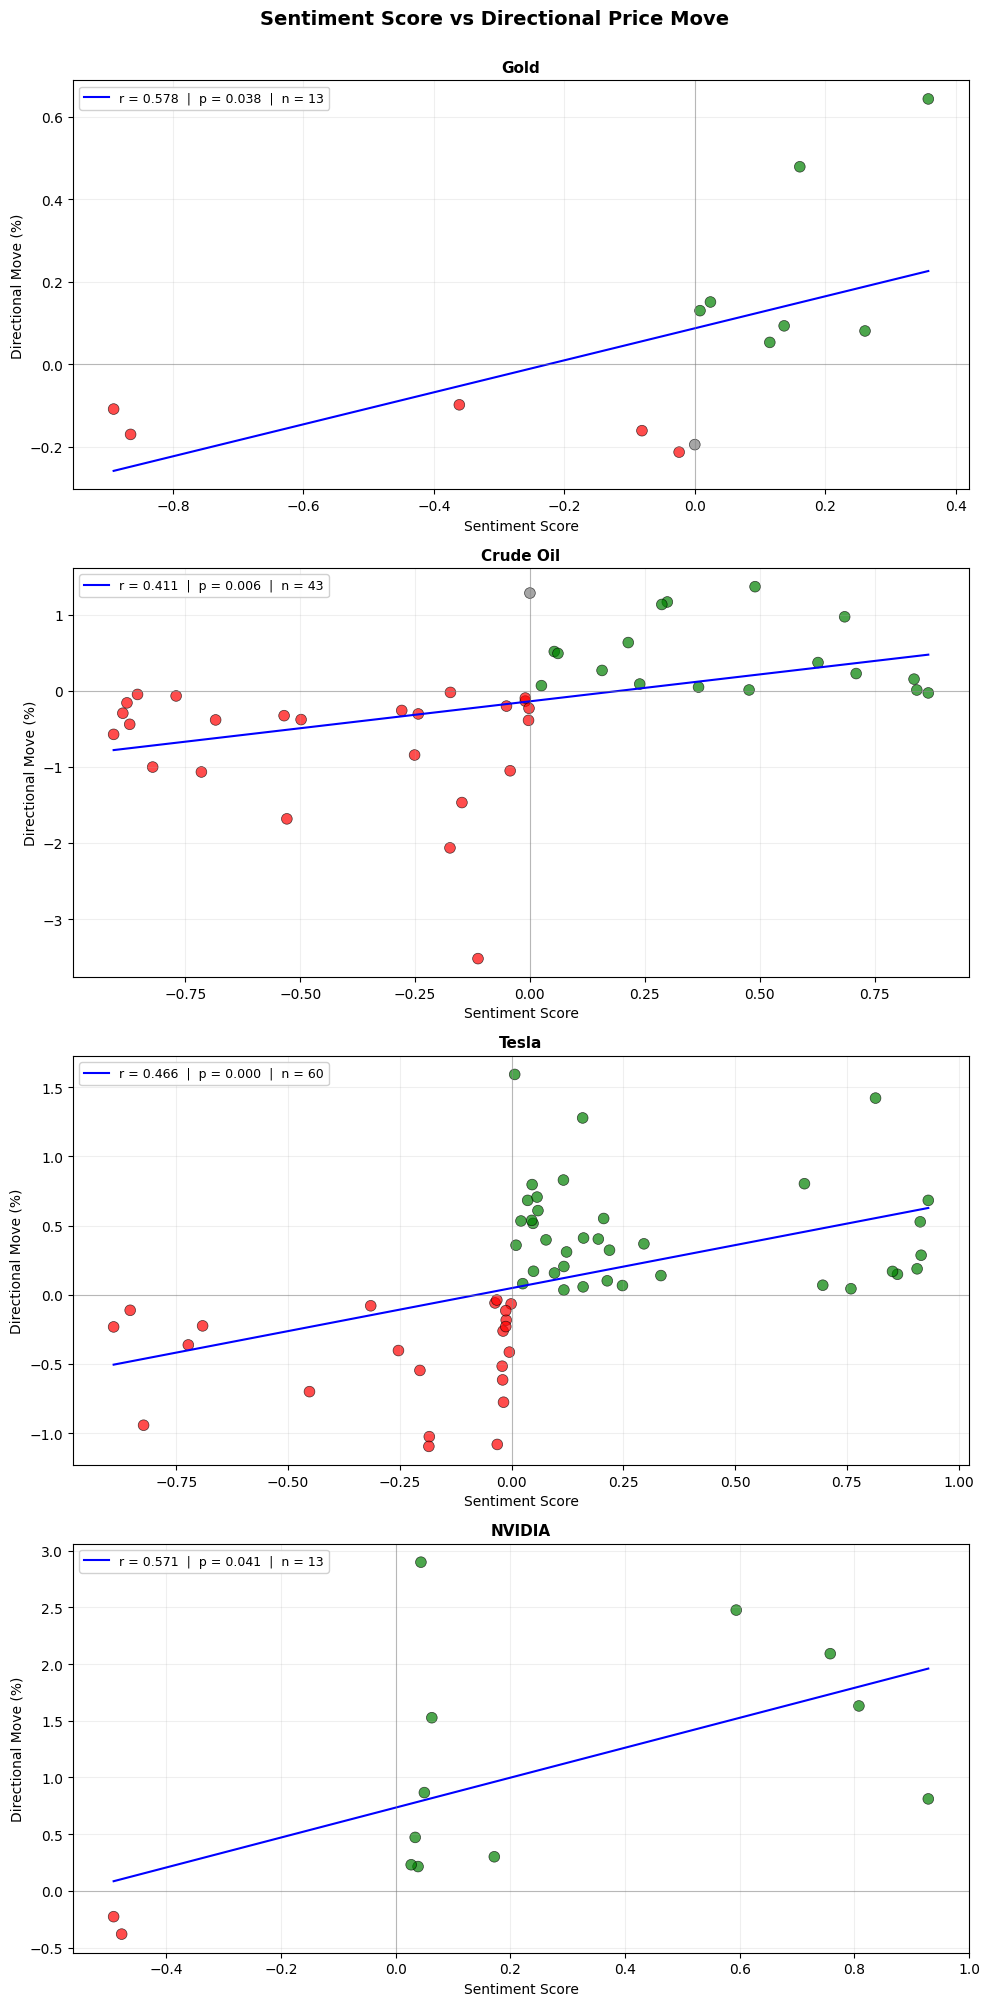

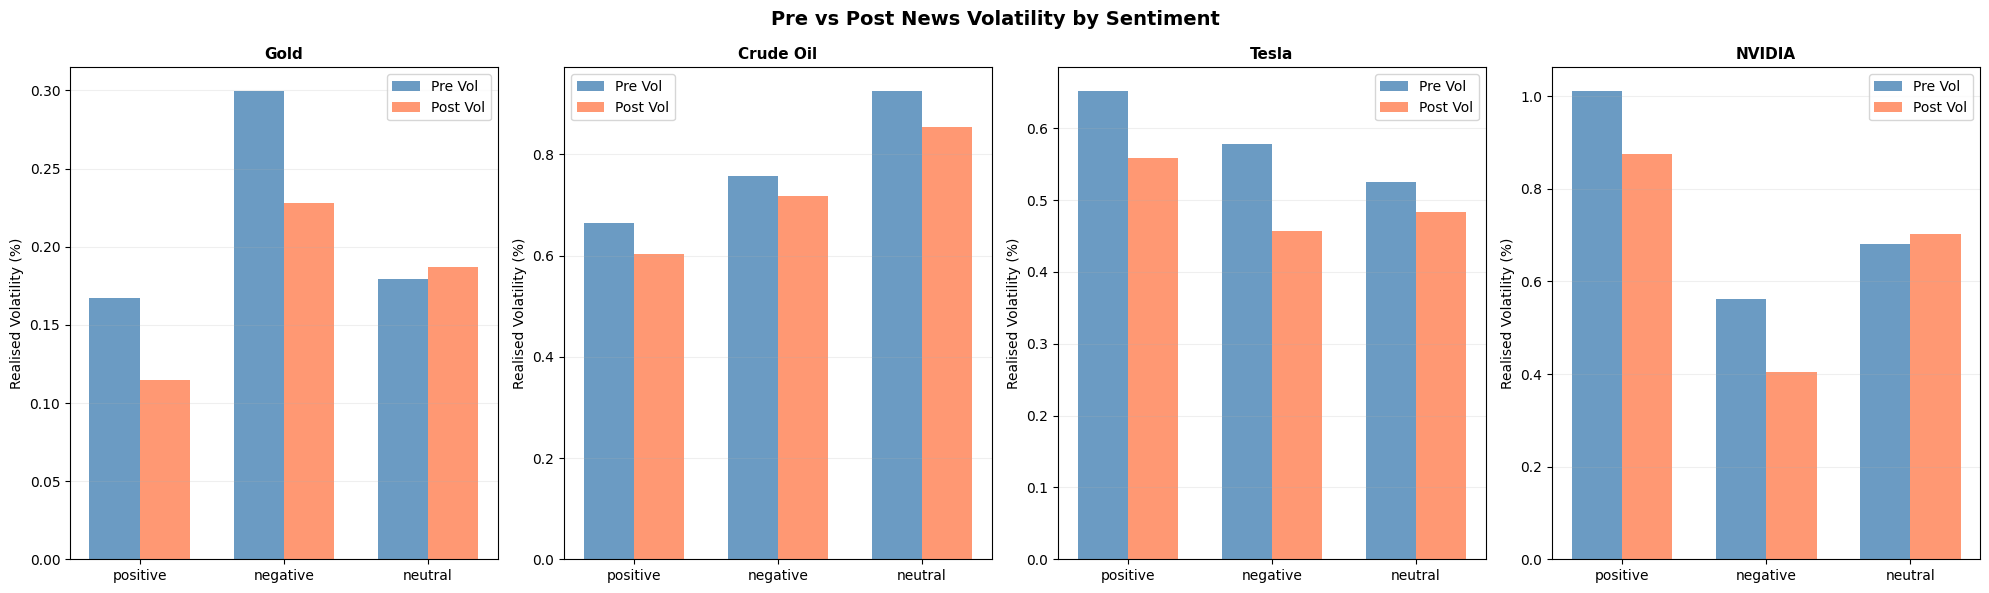

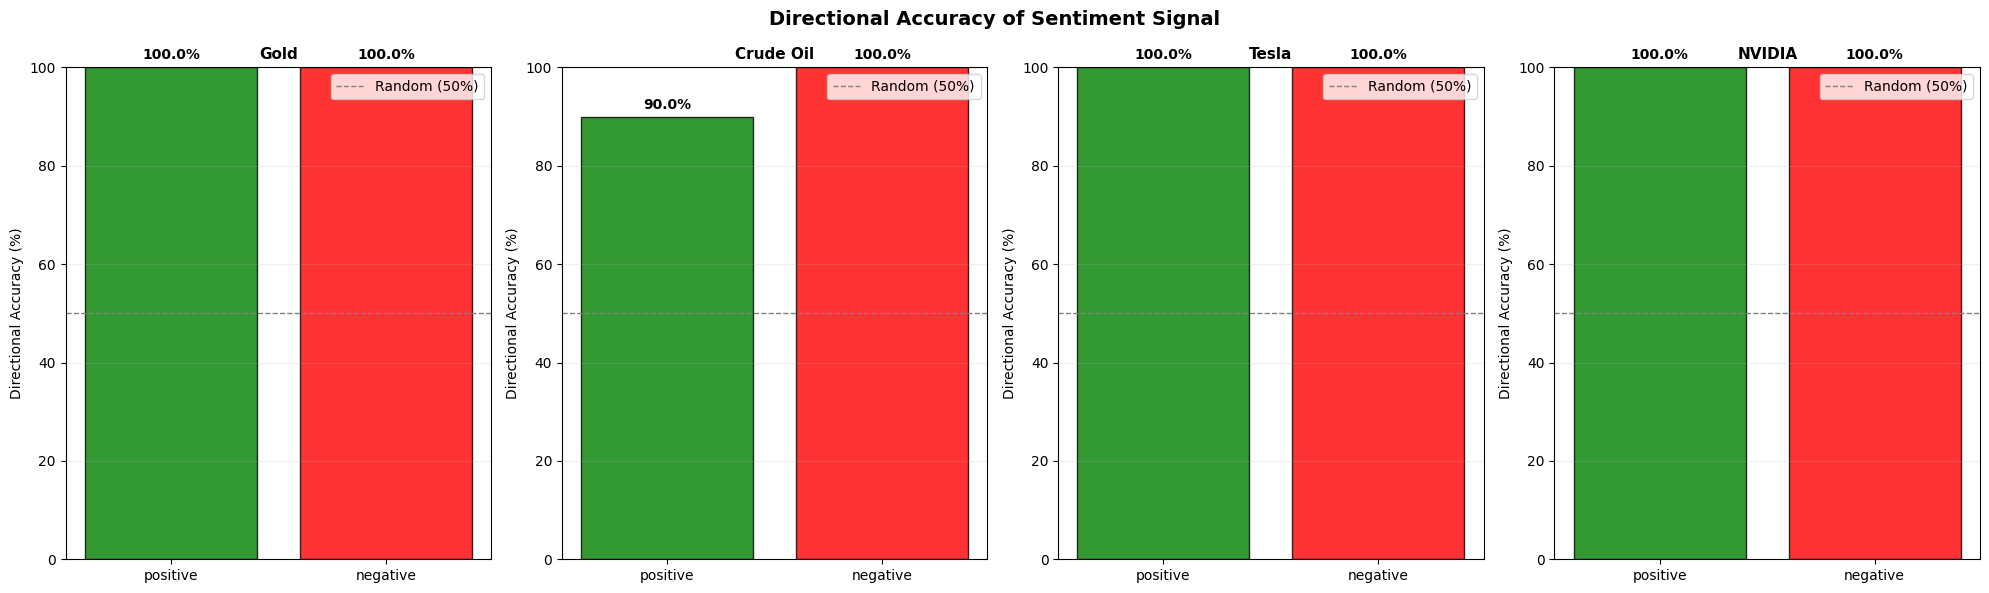

In [54]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

plot_data = {k: v for k, v in all_intraday_v2.items() if k != 'Silver'}

fig_height = 5 * len(plot_data)

# ── 1. Sentiment Score vs Directional Move ────────────────────────────────────
fig, axes = plt.subplots(len(plot_data), 1, figsize=(10, fig_height))
fig.suptitle('Sentiment Score vs Directional Price Move', fontsize=14, fontweight='bold', y = 1.001)

for ax, (name, df) in zip(axes, plot_data.items()):
    clean  = df.dropna(subset=['score', 'directional'])
    x      = clean['score'].values
    y      = clean['directional'].values
    colors = ['green' if s > 0 else 'red' if s < 0 else 'gray' for s in x]

    ax.scatter(x, y, c=colors, alpha=0.7, edgecolors='black', linewidths=0.5, s=60)

    if len(x) > 2:
        slope, intercept, r, p, _ = stats.linregress(x, y)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, slope * x_line + intercept, 'b-', linewidth=1.5,
                label=f'r = {r:.3f}  |  p = {p:.3f}  |  n = {len(x)}')
        ax.legend(loc='upper left', fontsize=9, framealpha=0.9)

    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.axhline(0, color='gray', linewidth=0.8, alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('Sentiment Score')
    ax.set_ylabel('Directional Move (%)')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('sentiment_vs_directional.png', dpi=120, bbox_inches='tight')
plt.show()


# ── 2. Pre vs Post Volatility by Sentiment Label ──────────────────────────────
fig, axes = plt.subplots(1, len(plot_data), figsize=(5 * len(plot_data), 6))
fig.suptitle('Pre vs Post News Volatility by Sentiment', fontsize=14, fontweight='bold')

for ax, (name, df) in zip(axes, plot_data.items()):
    labels    = ['positive', 'negative', 'neutral']
    pre_vals  = []
    post_vals = []

    for label in labels:
        subset = df[df['sentiment'] == label]
        pre_vals.append(subset['pre_vol'].mean()  if not subset.empty else 0)
        post_vals.append(subset['post_vol'].mean() if not subset.empty else 0)

    x     = np.arange(len(labels))
    width = 0.35

    ax.bar(x - width/2, pre_vals,  width, label='Pre Vol',  color='steelblue', alpha=0.8)
    ax.bar(x + width/2, post_vals, width, label='Post Vol', color='coral',     alpha=0.8)

    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Realised Volatility (%)')
    ax.legend()
    ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('pre_post_volatility.png', dpi=120, bbox_inches='tight')
plt.show()


# ── 3. Directional Accuracy ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(plot_data), figsize=(5 * len(plot_data), 6))
fig.suptitle('Directional Accuracy of Sentiment Signal', fontsize=14, fontweight='bold')

for ax, (name, df) in zip(axes, plot_data.items()):
    results = {}
    for label, expected_sign in [('positive', 1), ('negative', -1)]:
        subset = df[df['sentiment'] == label].dropna(subset=['directional'])
        if subset.empty:
            results[label] = 0
            continue
        correct          = (np.sign(subset['directional']) == expected_sign).sum()
        results[label]   = correct / len(subset) * 100

    bars = ax.bar(results.keys(), results.values(),
                  color=['green', 'red'], alpha=0.8, edgecolor='black')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_ylabel('Directional Accuracy (%)')
    ax.set_ylim(0, 100)
    ax.axhline(50, color='gray', linestyle='--', linewidth=1, label='Random (50%)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.2, axis='y')

    for bar, val in zip(bars, results.values()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('directional_accuracy.png', dpi=120, bbox_inches='tight')
plt.show()